# Predicción de Supervivencia (Titanic)

**Problema:** identificar qué factores (clase, sexo, edad, tarifa pagada, puerto de embarque, etc.) se asocian con la supervivencia de un pasajero.

**Objetivo analítico:** construir un modelo de clasificación supervisado que prediga si un pasajero sobrevive o no, a partir de sus características.

**Decisión ejecutiva que soporta:** priorizar políticas de seguridad/evacuación (ej. protocolos por clase o grupo demográfico) y entender qué variables tienen mayor peso en el riesgo de un pasajero.

## 1. Importación de librerías
Se cargan las librerías para manejo de datos, visualización, preprocesamiento, modelado y evaluación.

In [1]:
# Librerías para manejo de datos y arreglos numéricos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de sklearn para separar datos, preprocesar y modelar
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

# Configuración visual y de despliegue de columnas
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 2. Datos: obtención, descripción y comprensión

**Origen:** dataset público del Titanic (vía `seaborn`, tomado del repositorio oficial de datasets de seaborn).

**Estructura:** 891 registros, cada uno representa un pasajero.

**Variable objetivo:** survived (0 = no sobrevivió, 1 = sobrevivió).

**Variables relevantes:** pclass (clase del boleto), `sex`, `age`, `sibsp` (hermanos/cónyuges a bordo), `parch` (padres/hijos a bordo), fare (tarifa), `embarked` (puerto de embarque).

**Criterio de selección:** se descartan columnas redundantes o con demasiados nulos (`deck`, `embark_town`, `alive`, `class`, `who`, `adult_male`, `alone`) que duplican información ya presente en otras columnas o no aportan valor predictivo directo.

In [2]:
# Se carga el dataset del Titanic (viene incluido en seaborn)
df = sns.load_dataset("titanic")

# Se revisa cuántas filas y columnas tiene, y se ven las primeras filas
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Tipos de dato de cada columna y cuántos valores no nulos tiene
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
# Calidad inicial: nulos por columna (para saber qué hay que limpiar después)
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [5]:
# Descripción estadística de variables numéricas (media, min, max, cuartiles, etc.)
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Preprocesamiento

Pasos:
1. Se descartan columnas redundantes/no útiles.
2. Se separan variables predictoras (`X`) y objetivo (`y`) **antes** de dividir train/test, para evitar fuga de datos (data leakage).
3. Nulos en `age` y `embarked` se imputan (mediana y moda respectivamente) **dentro** del pipeline, ajustando el imputador solo con datos de entrenamiento.
4. Variables categóricas (`sex`, `embarked`, `pclass`) se codifican con One-Hot Encoding.
5. Variables numéricas (`age`, `fare`, `sibsp`, `parch`) se escalan con `StandardScaler`.
6. División train/test 80/20 estratificada por la variable objetivo, para conservar la proporción de sobrevivientes en ambos conjuntos.

In [6]:
# Nos quedamos solo con las columnas útiles (se descartan las redundantes vistas antes)
cols_utiles = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df_model = df[cols_utiles].copy()

# Separación de variables predictoras (X) y variable objetivo (y)
X = df_model.drop(columns=["survived"])
y = df_model["survived"]

# División train/test (80/20), estratificada para mantener la proporción de sobrevivientes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (712, 7) Test: (179, 7)


In [7]:
# Columnas numéricas y categóricas se tratan distinto
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["sex", "embarked", "pclass"]

# Numéricas: se rellenan nulos con la mediana y se escalan
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas: se rellenan nulos con la moda y se codifican con one-hot
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Se combinan ambos pipelines en un solo preprocesador
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])


## 4. Análisis exploratorio (EDA)

Se exploran distribuciones y relaciones entre las variables y la supervivencia, para detectar patrones (ej. si el sexo o la clase influyen en la tasa de supervivencia) y posibles problemas del dataset (desbalance de clases, outliers en `fare`).

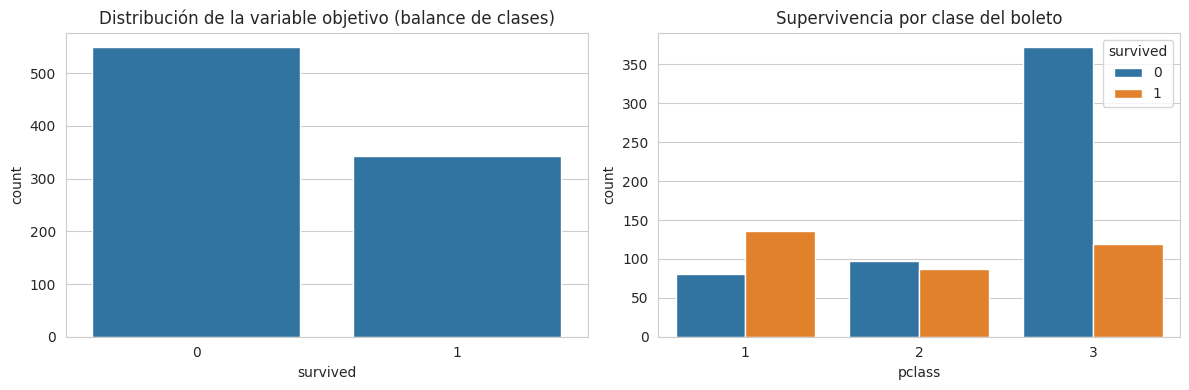

In [8]:
# Vemos si las clases (sobrevivió / no sobrevivió) están balanceadas
# y cómo se relaciona la supervivencia con la clase del boleto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_model, x="survived", ax=axes[0])
axes[0].set_title("Distribución de la variable objetivo (balance de clases)")

sns.countplot(data=df_model, x="pclass", hue="survived", ax=axes[1])
axes[1].set_title("Supervivencia por clase del boleto")
plt.tight_layout()
plt.show()


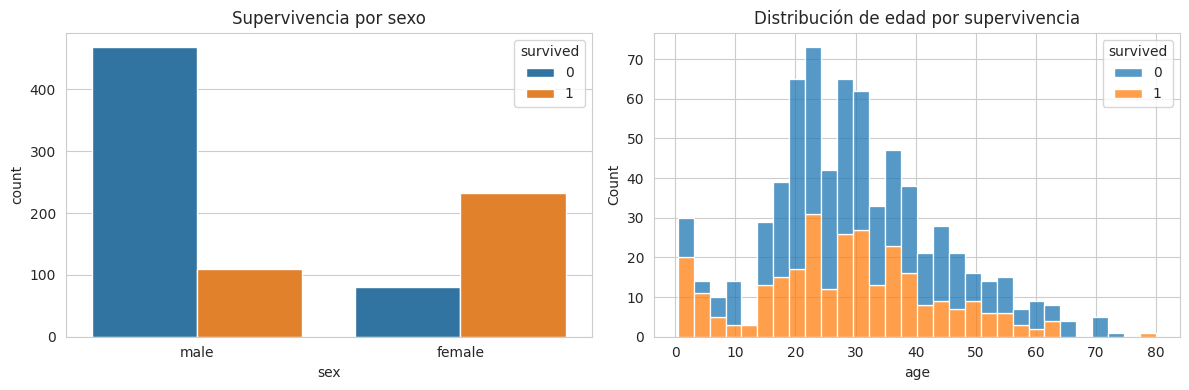

In [9]:
# Supervivencia por sexo y por edad, para ver qué grupos tuvieron más riesgo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df_model, x="sex", hue="survived", ax=axes[0])
axes[0].set_title("Supervivencia por sexo")

sns.histplot(data=df_model, x="age", hue="survived", multiple="stack", bins=30, ax=axes[1])
axes[1].set_title("Distribución de edad por supervivencia")
plt.tight_layout()
plt.show()


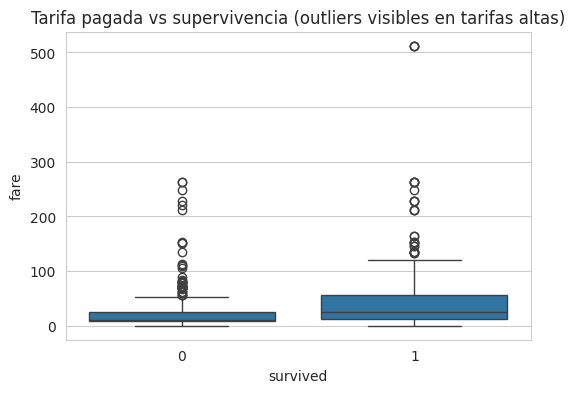

In [10]:
# Relación entre la tarifa pagada y la supervivencia (aquí se ven los outliers de tarifas altas)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model, x="survived", y="fare")
plt.title("Tarifa pagada vs supervivencia (outliers visibles en tarifas altas)")
plt.show()


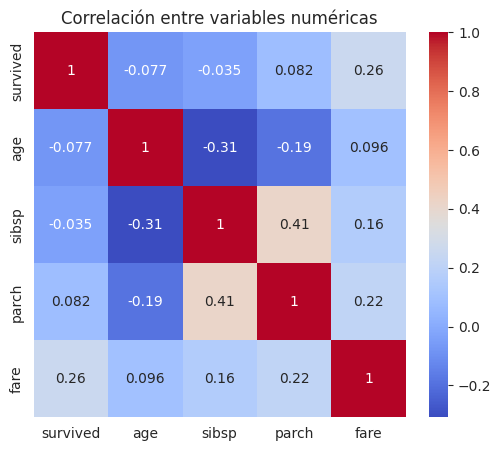

In [11]:
# Matriz de correlación entre variables numéricas, para ver qué tan relacionadas están entre sí
plt.figure(figsize=(6, 5))
sns.heatmap(df_model[["survived", "age", "sibsp", "parch", "fare"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()


## 5. Modelo: selección, justificación y entrenamiento

**Tipo de problema:** aprendizaje supervisado de clasificación binaria (`survived` = 0/1).

**Algoritmo elegido:** `RandomForestClassifier`. Se justifica porque:
- Maneja bien variables numéricas y categóricas combinadas.
- Es robusto a outliers (ej. tarifas extremas vistas en el EDA).
- Captura relaciones no lineales entre variables sin necesitar normalización estricta.
- Da una medida de importancia de variables, útil para el enfoque ejecutivo.

El modelo se entrena dentro de un `Pipeline` junto con el preprocesador, para que todo el flujo (imputación, escalado, codificación, modelo) se ajuste **solo** con datos de entrenamiento.

In [12]:
# Se arma el pipeline final: primero preprocesa, luego entrena el clasificador
# Random Forest porque maneja bien datos mixtos y es robusto a outliers
modelo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clasificador", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])

# Entrenamiento (solo con datos de train, así se evita fuga de datos)
modelo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

## 6. Evaluación del modelo

Se reportan métricas estándar de clasificación (exactitud, precisión, recall, F1), la matriz de confusión y la curva ROC/AUC, y se interpretan en función del problema (ej. qué tan bien detecta el modelo a los sobrevivientes reales, y qué tantos falsos positivos/negativos comete).

In [13]:
# Predicciones sobre el conjunto de prueba (datos que el modelo no vio en entrenamiento)
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de sobrevivir

# Métricas principales de clasificación
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1-score: ", round(f1_score(y_test, y_pred), 3))
print("AUC:      ", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))


Accuracy:  0.804
Precision: 0.854
Recall:    0.594
F1-score:  0.701
AUC:       0.846

               precision    recall  f1-score   support

No sobrevivió       0.79      0.94      0.85       110
   Sobrevivió       0.85      0.59      0.70        69

     accuracy                           0.80       179
    macro avg       0.82      0.77      0.78       179
 weighted avg       0.81      0.80      0.80       179



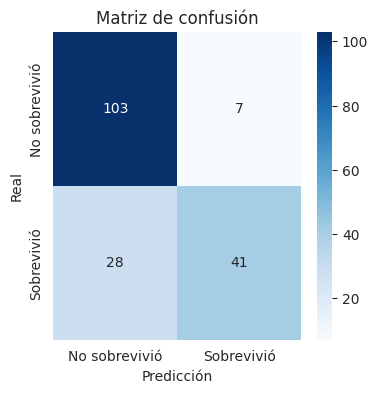

In [14]:
# Matriz de confusión: para ver aciertos y errores (falsos positivos/negativos)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No sobrevivió", "Sobrevivió"],
            yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()


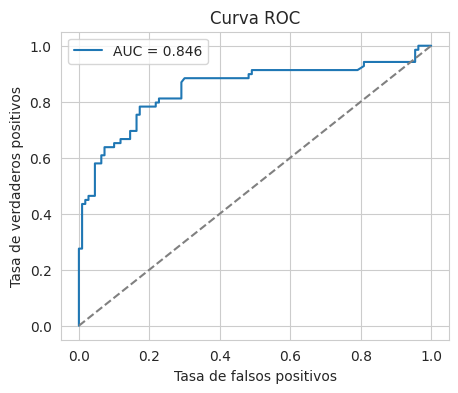

In [15]:
# Curva ROC: qué tan bien separa el modelo las dos clases en distintos umbrales
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # línea de referencia (modelo aleatorio)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()


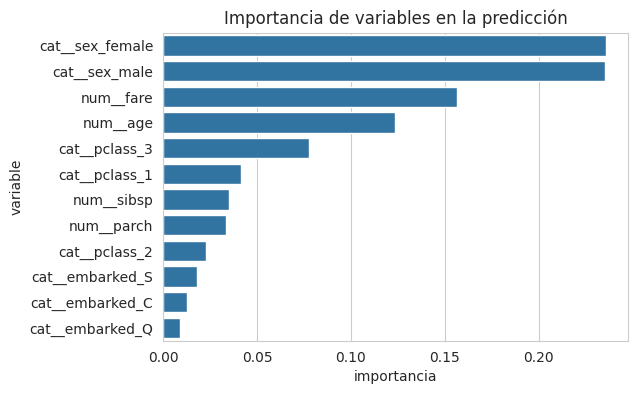

,variable,importancia
4,cat__sex_female,0.235779
5,cat__sex_male,0.235239
1,num__fare,0.156353
0,num__age,0.123267
11,cat__pclass_3,0.077541
9,cat__pclass_1,0.041492
2,num__sibsp,0.035190
3,num__parch,0.033195
10,cat__pclass_2,0.022620
8,cat__embarked_S,0.017973


In [16]:
# Importancia de variables: qué tanto pesó cada una en las decisiones del modelo
# (esto sirve para el enfoque ejecutivo, para explicar el "por qué" del modelo)
importancias = modelo.named_steps["clasificador"].feature_importances_
nombres = modelo.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"variable": nombres, "importancia": importancias}) \
    .sort_values("importancia", ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=imp_df, x="importancia", y="variable")
plt.title("Importancia de variables en la predicción")
plt.show()
imp_df


## 7. Predicción con datos nuevos

Se crea un pasajero hipotético nuevo, con las mismas columnas usadas en el entrenamiento, y se pasa por el **mismo pipeline** (mismo preprocesamiento) para obtener su predicción. Esto demuestra que el modelo es reutilizable ante datos que nunca vio.

In [17]:
# Pasajero hipotético nuevo, con las mismas columnas que usó el modelo en entrenamiento
pasajero_nuevo = pd.DataFrame([{
    "pclass": 3,
    "sex": "female",
    "age": 22,
    "sibsp": 1,
    "parch": 0,
    "fare": 7.25,
    "embarked": "S"
}])

# Se predice usando el mismo pipeline (mismo preprocesamiento que en entrenamiento)
pred = modelo.predict(pasajero_nuevo)[0]
proba = modelo.predict_proba(pasajero_nuevo)[0, 1]

print("Predicción:", "Sobrevive" if pred == 1 else "No sobrevive")
print(f"Probabilidad de supervivencia: {proba:.2%}")


Predicción: Sobrevive
Probabilidad de supervivencia: 51.28%


## 8. Conclusiones y recomendaciones

- El sexo y la clase del boleto resultaron ser las variables con mayor peso en la predicción de supervivencia, seguidas de la tarifa pagada y la edad.
- El modelo alcanza un desempeño aceptable (ver métricas en la sección 6), suficiente para identificar patrones de riesgo, aunque no debe usarse como única fuente para decisiones críticas sin validación adicional.
- **Riesgo/limitación:** el dataset es histórico y de tamaño reducido (891 registros); las conclusiones son ilustrativas del método, no generalizables a otros contextos sin reentrenamiento.
- **Recomendación:** priorizar el análisis de variables como clase y composición familiar a bordo (`sibsp`/`parch`) al diseñar políticas o protocolos que dependan de perfiles de riesgo similares.